# Regional Lecanemab effect: preliminary exploration

**Question** (from `context/proposal.md`): we know brains with more plaque lose proportionally
more under Lecanemab. Does that *proportion* differ between brain regions, beyond what each
region's baseline plaque load already predicts?

Before designing an experiment around that question, this notebook checks, at the **coarse**
atlas level (`seg-coarse`: 12 structures × L/R = 24 regions):

1. **Q1:** plaque load per region is consistent across control (PBS) mice;
2. **Q2:** how PBS and Lecanemab differ, region by region;
3. **Beyond baseline:** whether regional differences in the treatment effect survive once each
   region's baseline burden is accounted for.

Everything is built from the per-subject `mergedsegstats` tables explored in
`data_exploration.ipynb`, joined across all subjects with `participants.tsv`.

In [1]:
import warnings
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import patsy
import statsmodels.formula.api as smf
from matplotlib.lines import Line2D
from matplotlib.ticker import FuncFormatter, LogLocator, NullFormatter
from scipy import stats
from statsmodels.stats.multitest import multipletests
from statsmodels.tools.sm_exceptions import ConvergenceWarning

BIDS_PATH = Path("/home/UWO/oolejar/lightsheet/mouse_app_lecanemab_ki3_aggregated/bids")
DERIVATIVES_PATH = Path(
    "/home/UWO/oolejar/lightsheet/mouse_app_lecanemab_ki3_aggregated/derivatives/spimquant-v0.9.0_lantern"
)
PARTICIPANTS_TSV = BIDS_PATH / "participants.tsv"

SEG_LEVEL = "coarse"
# Primary metric. Switch to "Abeta+fieldfrac" to re-run the whole notebook on plaque burden
# (% of tissue occupied) instead of plaque count per mm^3
METRIC = "Abeta+density"
APPLY_QC_EXCLUSIONS = True

N_BOOT = 1000  # cheap bootstraps (ratios of means)
N_BOOT_MODEL = 500  # bootstraps that refit the mixed models (~0.2 s each)
N_SPLITS = 1000  # split-half draws
N_PERM = 1000  # permutations for the model comparisons; 200 is enough for a quick run
RNG_SEED = 0

ARMS = ["PBS", "Lecanemab"]

In [2]:
# One colour per arm, used everywhere. Batch and sex are secondary encodings (marker shape, fill),
# not extra hues, so no figure needs more than two series colours
GROUP_COLORS = {"PBS": "#2a78d6", "Lecanemab": "#eb6834"}
BATCH_MARKERS = {1: "o", 2: "s", 3: "^", 4: "D"}
INK, INK_2, MUTED, GRID, SURFACE = "#0b0b0b", "#52514e", "#8a8985", "#e6e5e1", "#fcfcfb"

plt.rcParams.update(
    {
        "figure.facecolor": SURFACE,
        "axes.facecolor": SURFACE,
        "savefig.facecolor": SURFACE,
        "axes.edgecolor": MUTED,
        "axes.labelcolor": INK_2,
        "xtick.color": INK_2,
        "ytick.color": INK_2,
        "text.color": INK,
        "axes.spines.top": False,
        "axes.spines.right": False,
        "axes.grid": True,
        "grid.color": GRID,
        "grid.linewidth": 0.8,
        "axes.axisbelow": True,
        "lines.linewidth": 2,
        "font.size": 10,
        "axes.titlesize": 11,
        "axes.titleweight": "bold",
        "axes.titlelocation": "left",
        "legend.frameon": False,
        "figure.dpi": 110,
    }
)
pd.set_option("display.width", 200)


def plain_log_axes(ax, axes="xy"):
    """Log scale with plain-number ticks at 1-2-5 steps instead of 10^n notation."""
    for axis in [ax.xaxis if a == "x" else ax.yaxis for a in axes]:
        axis.set_major_locator(LogLocator(subs=(1, 2, 5)))
        axis.set_major_formatter(FuncFormatter(lambda v, _: f"{v:g}"))
        axis.set_minor_formatter(NullFormatter())


def label_points(ax, xs, ys, labels, fontsize=8):
    """Direct-label points, giving each label the first side that doesn't hit a point or a placed label."""
    ax.figure.canvas.draw()  # fixes the data -> pixel transform for the final limits
    scale = ax.figure.dpi / 72  # offset points -> pixels
    points = ax.transData.transform(np.column_stack([xs, ys]))
    height = fontsize * scale
    candidates = [((6, -3), "left"), ((-6, -3), "right"), ((6, 6), "left"), ((6, -12), "left"), ((-6, 6), "right"), ((-6, -12), "right")]
    placed = []
    for (px, py), x_data, y_data, text in zip(points, xs, ys, labels):
        width = 0.62 * fontsize * scale * len(text)
        boxes = []
        for (dx, dy), ha in candidates:
            x0 = px + dx * scale - (width if ha == "right" else 0)
            y0 = py + dy * scale
            box = (x0, y0, x0 + width, y0 + height)
            hits = sum(box[0] - 4 < qx < box[2] + 4 and box[1] - 4 < qy < box[3] + 4 for qx, qy in points if (qx, qy) != (px, py))
            hits += sum(not (box[2] < b[0] or b[2] < box[0] or box[3] < b[1] or b[3] < box[1]) for b in placed)
            boxes.append((hits, (dx, dy), ha, box))
        hits, offset, ha, box = min(boxes, key=lambda b: b[0])  # min keeps the earliest candidate on ties
        placed.append(box)
        ax.annotate(text, (x_data, y_data), xytext=offset, textcoords="offset points",
                    ha=ha, va="bottom", fontsize=fontsize, color=INK_2)

## 1. Aggregate across subjects

One long table: one row per subject × atlas region, with the treatment, batch and sex columns
from `participants.tsv`. Label 0 (`Unknown_Label_0`, objects outside every atlas region) is kept
apart for QC and dropped from the analysis.

In [3]:
def load_mergedsegstats(seg_level):
    """Stack every subject's mergedsegstats table for one atlas granularity into one long table."""
    pattern = f"sub-*/ses-exvivo/tabular/*_seg-{seg_level}_from-ABAv3_desc-lantern_mergedsegstats.tsv"
    tables = []
    for tsv in sorted(DERIVATIVES_PATH.glob(pattern)):
        table = pd.read_csv(tsv, sep="\t")
        table["participant_id"] = tsv.name.split("_")[0]
        tables.append(table)
    # 3 subjects carry an extra Abeta+vesseldist column; concat leaves it NaN for the rest
    return pd.concat(tables, ignore_index=True)


participants = pd.read_csv(PARTICIPANTS_TSV, sep="\t")
stats_long = load_mergedsegstats(SEG_LEVEL).merge(
    participants[["participant_id", "treatment", "batch_id", "sex"]],
    on="participant_id",
    how="left",
    validate="many_to_one",
)
assert stats_long["participant_id"].nunique() == len(participants) == 36
assert (stats_long.groupby("participant_id").size() == 25).all()  # 24 regions + label 0

# Region names, hemisphere and abbreviations come from the atlas lookup table, whose row order
# (L/R pairs, cortex -> brainstem -> cerebellum) is used as the anatomical order on every axis
atlas_labels = pd.read_csv(DERIVATIVES_PATH / "tpl-ABAv3" / f"tpl-ABAv3_seg-{SEG_LEVEL}_dseg.tsv", sep="\t")
atlas_labels["hemi"] = atlas_labels["name"].str[0]
atlas_labels["structure"] = atlas_labels["name"].str[2:]
REGION_ORDER = atlas_labels["name"].tolist()
STRUCTURE_ORDER = atlas_labels["structure"].drop_duplicates().tolist()
STRUCTURE_ABBR = dict(zip(atlas_labels["structure"], atlas_labels["abbreviation"].str[2:]))

unlabelled = stats_long[stats_long["index"] == 0]
regions = stats_long[stats_long["index"] != 0].merge(
    atlas_labels[["index", "hemi", "structure"]], on="index", validate="many_to_one"
)
assert set(regions["name"]) == set(REGION_ORDER)
assert (regions[METRIC] > 0).all()  # everything below works on log(METRIC)

print(participants["treatment"].value_counts(dropna=False).to_string())
regions.head()

treatment
PBS          16
Lecanemab    16
NaN           2
N control     1
P control     1


,index,name,Abeta+nvoxels,Abeta+stain,Abeta+count,Abeta+fieldfrac,Abeta+volume,Abeta+density,participant_id,Abeta+vesseldist,treatment,batch_id,sex,hemi,structure
0,1,L_Isocortex,778761248.0,Abeta,294952.0,5.876568,65.844967,4479.491954,sub-AS10M6,NaN,PBS,3,M,L,Isocortex
1,2,R_Isocortex,702907008.0,Abeta,278385.0,5.329216,66.160159,4207.743838,sub-AS10M6,NaN,PBS,3,M,R,Isocortex
2,3,L_Olfactory areas,178467496.0,Abeta,73858.0,3.589795,24.249571,3045.744648,sub-AS10M6,NaN,PBS,3,M,L,Olfactory areas
3,4,R_Olfactory areas,200608720.0,Abeta,80036.0,4.245310,23.879149,3351.710730,sub-AS10M6,NaN,PBS,3,M,R,Olfactory areas
4,5,L_Hippocampal formation,167488400.0,Abeta,78067.0,3.625969,22.941002,3402.946466,sub-AS10M6,NaN,PBS,3,M,L,Hippocampal formation


**Groups.** PBS is the control arm for the proposal (16 mice, all 4 batches). `N control` and
`P control` are single staining-control mice. The N control is used only as a background /
false-positive floor, and the two WT mice (no treatment) are not used.

**Pooling hemispheres.** Section 5 works on 12 bilateral structures. Pooling sums counts and
volumes and then divides (density = Σcount / Σvolume), rather than averaging two densities.
Fieldfrac is volume-weighted the same way. If QC removes one hemisphere, the structure is
estimated from the other one.

In [4]:
POOLED_COLUMNS = ["Abeta+count", "Abeta+volume", "_fieldfrac_x_volume"]


def pool_regions(region_table, keys):
    """Pool regions within `keys`: density = sum(count) / sum(volume); fieldfrac volume-weighted."""
    table = region_table.assign(
        _fieldfrac_x_volume=region_table["Abeta+fieldfrac"] * region_table["Abeta+volume"]
    )
    pooled = table.groupby(keys, as_index=False, dropna=False)[POOLED_COLUMNS].sum()
    pooled["Abeta+density"] = pooled["Abeta+count"] / pooled["Abeta+volume"]
    pooled["Abeta+fieldfrac"] = pooled["_fieldfrac_x_volume"] / pooled["Abeta+volume"]
    return pooled.drop(columns="_fieldfrac_x_volume")


MOUSE_KEYS = ["participant_id", "treatment", "batch_id", "sex"]


def to_bilateral(region_table):
    return pool_regions(region_table, MOUSE_KEYS + ["structure"])


# Sanity check: pooled density is recomputed from summed counts and volumes
_check = to_bilateral(regions)
_one = regions[(regions["participant_id"] == "sub-AS10M6") & (regions["structure"] == "Isocortex")]
assert np.isclose(
    _check.query("participant_id == 'sub-AS10M6' and structure == 'Isocortex'")["Abeta+density"].item(),
    _one["Abeta+count"].sum() / _one["Abeta+volume"].sum(),
)

## 2. QC before interpreting anything

### Objects outside the atlas

The fraction of a mouse's detected objects that land in label 0. This checks registration and
masking: a mouse that stands out here may have region counts that are off too.

,count,mean,std,min,25%,50%,75%,max
treatment,,,,,,,,
Lecanemab,16.0,0.174,0.026,0.132,0.153,0.178,0.197,0.211
N control,1.0,0.402,NaN,0.402,0.402,0.402,0.402,0.402
P control,1.0,0.160,NaN,0.160,0.160,0.160,0.160,0.160
PBS,16.0,0.145,0.022,0.105,0.131,0.145,0.156,0.188
NaN,2.0,0.491,0.032,0.469,0.480,0.491,0.502,0.514


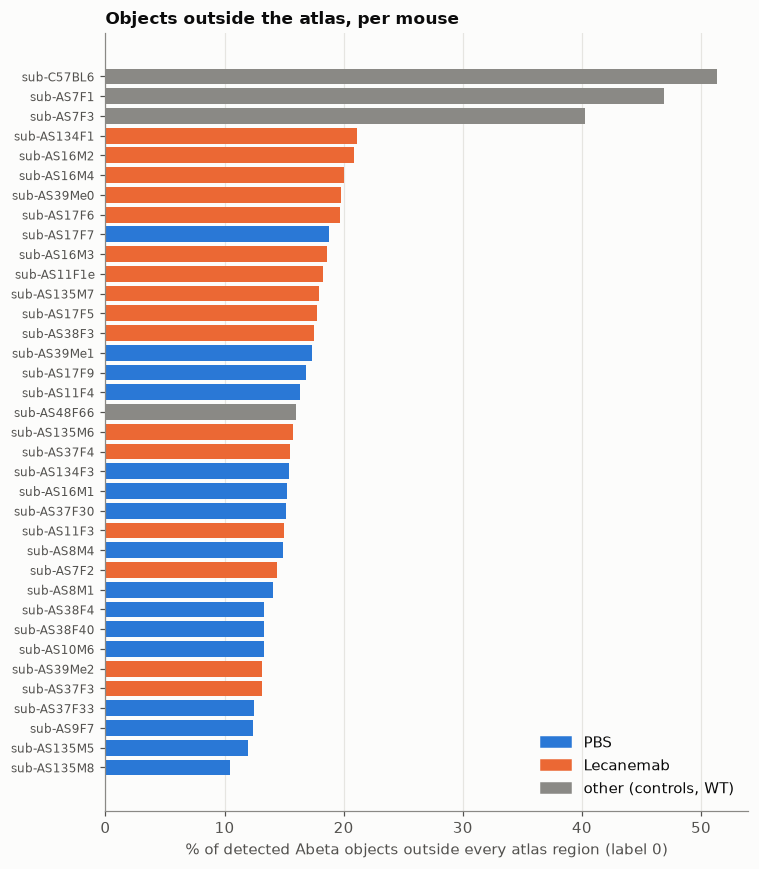

In [5]:
unlabelled_frac = (
    unlabelled.set_index("participant_id")["Abeta+count"]
    / stats_long.groupby("participant_id")["Abeta+count"].sum()
).rename("unlabelled_frac")
unlabelled_qc = (
    participants.set_index("participant_id")[["treatment", "batch_id"]]
    .join(unlabelled_frac)
    .sort_values("unlabelled_frac")
)

fig, ax = plt.subplots(figsize=(7, 8))
bar_colors = [GROUP_COLORS.get(t, MUTED) for t in unlabelled_qc["treatment"]]
ax.barh(unlabelled_qc.index, unlabelled_qc["unlabelled_frac"] * 100, color=bar_colors, height=0.8)
ax.set_xlabel("% of detected Abeta objects outside every atlas region (label 0)")
ax.set_title("Objects outside the atlas, per mouse")
ax.grid(axis="y", visible=False)
ax.tick_params(axis="y", labelsize=8)
ax.legend(
    handles=[plt.Rectangle((0, 0), 1, 1, color=c) for c in [*GROUP_COLORS.values(), MUTED]],
    labels=[*GROUP_COLORS, "other (controls, WT)"],
    loc="lower right",
)
plt.tight_layout()
unlabelled_qc.groupby("treatment", dropna=False)["unlabelled_frac"].describe().round(3)

### Region-level exclusions from `QC_notes`

The QC notes in `participants.tsv` are turned into region-level exclusions below. Two notes
don't map to a coarse region and are left in: sub-AS17F9 (bubble at the base of the brain) and
sub-AS16M3 (bubble in the lateral ventricle, which isn't an atlas region). `APPLY_QC_EXCLUSIONS`
toggles the mask, and section 5 reports results both ways.

In [6]:
QC_EXCLUDE = {
    # "Bottom of brain is very blurry ... would not include deep inferior subcortical structures or brainstem"
    "sub-AS134F3": [f"{h}_{s}" for h in "LR" for s in ["Hypothalamus", "Midbrain", "Pons", "Medulla"]],
    # "Right side tissue tear in hippocampal-retrohippocampal extension. Also some cortical tearing"
    "sub-AS11F4": ["R_Hippocampal formation", "R_Isocortex"],
    "sub-AS16M1": ["L_Olfactory areas"],  # missing left olfactory bulb
    "sub-AS17F5": ["L_Olfactory areas"],  # damage to left olfactory bulb
    "sub-AS16M4": ["R_Isocortex"],  # right posterior cortical tissue damage
}
assert all(name in REGION_ORDER for names in QC_EXCLUDE.values() for name in names)


def apply_qc_mask(region_table, exclude=QC_EXCLUDE):
    drop = pd.Series(False, index=region_table.index)
    for participant_id, names in exclude.items():
        drop |= (region_table["participant_id"] == participant_id) & region_table["name"].isin(names)
    return region_table[~drop]


def build_tables(apply_qc):
    """Hemisphere-level and bilateral tables for the PBS and Lecanemab arms."""
    region_table = apply_qc_mask(regions) if apply_qc else regions
    region_table = region_table[region_table["treatment"].isin(ARMS)]
    return region_table, to_bilateral(region_table)


arms_hemi, arms_bilat = build_tables(APPLY_QC_EXCLUSIONS)
mice = arms_hemi[MOUSE_KEYS].drop_duplicates()
assert mice["treatment"].value_counts().to_dict() == {"PBS": 16, "Lecanemab": 16}
print(f"QC exclusions applied: {APPLY_QC_EXCLUSIONS}; {len(regions[regions.treatment.isin(ARMS)]) - len(arms_hemi)} "
      "subject-region rows removed")
pd.crosstab(mice["batch_id"], [mice["treatment"], mice["sex"]])

QC exclusions applied: True; 13 subject-region rows removed


treatment Lecanemab    PBS   
sex               F  M   F  M
batch_id                     
1                 1  2   1  2
2                 3  2   3  2
3                 3  0   3  2
4                 2  3   2  1

### Does treatment change region volume?

Density is count / volume. If Lecanemab changed region volume (atrophy, swelling), the density
would change even with the same number of plaques. The volume ratio should sit near 1.

In [7]:
volume_rows = []
for name, group in arms_hemi.groupby("name"):
    pbs_vol = group.loc[group["treatment"] == "PBS", "Abeta+volume"]
    leca_vol = group.loc[group["treatment"] == "Lecanemab", "Abeta+volume"]
    volume_rows.append(
        {
            "region": name,
            "PBS_mm3": pbs_vol.mean(),
            "Lecanemab_mm3": leca_vol.mean(),
            "ratio": leca_vol.mean() / pbs_vol.mean(),
            "p_welch": stats.ttest_ind(leca_vol, pbs_vol, equal_var=False).pvalue,
        }
    )
volume_check = pd.DataFrame(volume_rows).set_index("region").loc[REGION_ORDER]
volume_check["q_fdr"] = multipletests(volume_check["p_welch"], method="fdr_bh")[1]
print(f"volume ratio Lecanemab/PBS across regions: {volume_check['ratio'].min():.3f} - {volume_check['ratio'].max():.3f}")
volume_check.round(3)

volume ratio Lecanemab/PBS across regions: 0.935 - 0.984


,PBS_mm3,Lecanemab_mm3,ratio,p_welch,q_fdr
region,,,,,
L_Isocortex,67.429,64.187,0.952,0.156,0.260
R_Isocortex,65.387,64.353,0.984,0.518,0.518
L_Olfactory areas,25.134,24.050,0.957,0.201,0.260
R_Olfactory areas,24.834,23.928,0.963,0.254,0.282
L_Hippocampal formation,23.180,22.108,0.954,0.178,0.260
R_Hippocampal formation,22.639,22.127,0.977,0.370,0.386
L_Cortical subplate,4.823,4.614,0.957,0.206,0.260
R_Cortical subplate,4.839,4.611,0.953,0.175,0.260
L_Striatum,24.129,23.169,0.960,0.238,0.282


### Background floor: the N-control mouse

The N control is a staining control, so objects detected in it are background or false
positives. It gives a floor for each region: a treated region whose value is close to the floor
can't show much more removal, whatever the biology.

In [8]:
ncontrol_hemi = regions[regions["treatment"] == "N control"].set_index("name")[METRIC]
ncontrol_bilat = to_bilateral(regions[regions["treatment"] == "N control"]).set_index("structure")[METRIC]

floor_check = pd.DataFrame(
    {
        "N_control": ncontrol_bilat,
        "PBS_mean": arms_bilat[arms_bilat["treatment"] == "PBS"].groupby("structure")[METRIC].mean(),
        "Lecanemab_mean": arms_bilat[arms_bilat["treatment"] == "Lecanemab"].groupby("structure")[METRIC].mean(),
    }
).loc[STRUCTURE_ORDER]
floor_check["Lecanemab_over_floor"] = floor_check["Lecanemab_mean"] / floor_check["N_control"]
# A region counts as "near the floor" when the treated mean is within 2x of background
FLOOR_FACTOR = 2
floor_check["near_floor"] = floor_check["Lecanemab_over_floor"] < FLOOR_FACTOR
floor_check.round(2)

,N_control,PBS_mean,Lecanemab_mean,Lecanemab_over_floor,near_floor
structure,,,,,
Isocortex,307.30,3784.60,1827.02,5.95,False
Olfactory areas,201.45,2451.08,1031.46,5.12,False
Hippocampal formation,106.70,2844.23,1499.04,14.05,False
Cortical subplate,23.90,2653.52,1549.14,64.82,False
Striatum,64.87,1506.02,895.42,13.80,False
Pallidum,63.04,1021.45,656.59,10.42,False
Thalamus,84.18,886.77,632.40,7.51,False
Hypothalamus,37.02,948.56,496.66,13.42,False
Midbrain,112.99,1238.68,741.40,6.56,False


## 3. Q1: Is plaque load consistent across PBS mice?

Bars show the PBS mean, and whiskers ±1 SD. Each point is one mouse: marker shape = batch,
filled = female, hollow = male. The grey tick is the N-control floor.

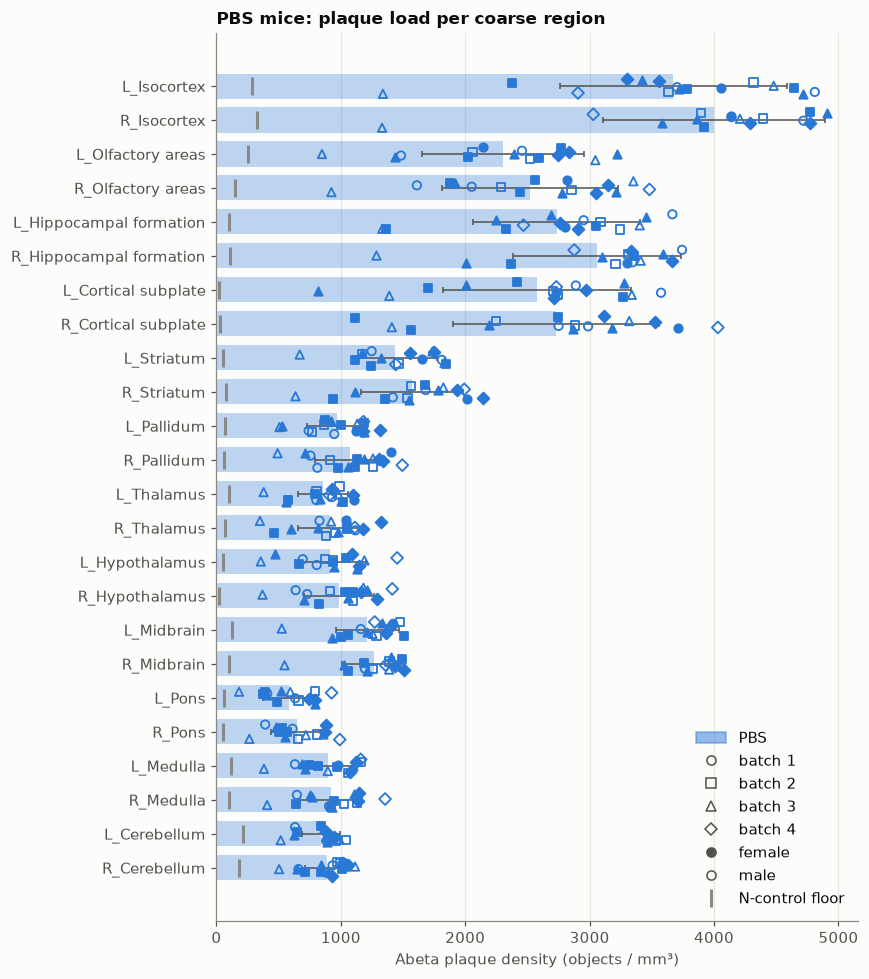

In [9]:
def plot_bars_with_points(ax, region_table, metric, arms, floor=None, order=REGION_ORDER, jitter_seed=0):
    """Horizontal mean±SD bars per region, one bar per arm, with every mouse overlaid."""
    rng = np.random.default_rng(jitter_seed)
    n_arms = len(arms)
    bar_height = 0.8 / n_arms
    y_base = np.arange(len(order))
    for arm_i, arm in enumerate(arms):
        color = GROUP_COLORS[arm]
        offset = (arm_i - (n_arms - 1) / 2) * bar_height
        arm_table = region_table[region_table["treatment"] == arm]
        summary = arm_table.groupby("name")[metric].agg(["mean", "std"]).reindex(order)
        # height slightly under the slot so neighbouring bars keep a visible gap
        ax.barh(y_base + offset, summary["mean"], height=bar_height * 0.92, color=color, alpha=0.3, label=arm)
        ax.errorbar(summary["mean"], y_base + offset, xerr=summary["std"], fmt="none", ecolor=INK_2, elinewidth=1, capsize=2)
        y_of = dict(zip(order, y_base + offset))
        for (batch, sex), mouse_rows in arm_table.groupby(["batch_id", "sex"]):
            y = mouse_rows["name"].map(y_of) + rng.uniform(-bar_height * 0.3, bar_height * 0.3, len(mouse_rows))
            ax.scatter(
                mouse_rows[metric],
                y,
                s=30,
                marker=BATCH_MARKERS[batch],
                facecolors=color if sex == "F" else "none",
                edgecolors=color,
                linewidths=1.2,
                zorder=3,
            )
    if floor is not None:
        ax.scatter(floor.reindex(order), y_base, marker="|", s=150, color=MUTED, linewidths=2, zorder=4)
    ax.set_yticks(y_base, order)
    ax.invert_yaxis()
    ax.grid(axis="y", visible=False)


def point_legend(ax, arms, floor=True, **kwargs):
    handles = [plt.Rectangle((0, 0), 1, 1, color=GROUP_COLORS[a], alpha=0.5) for a in arms]
    labels = list(arms)
    handles += [Line2D([], [], ls="", marker=m, color=INK_2, markerfacecolor="none") for m in BATCH_MARKERS.values()]
    labels += [f"batch {b}" for b in BATCH_MARKERS]
    handles += [
        Line2D([], [], ls="", marker="o", color=INK_2),
        Line2D([], [], ls="", marker="o", color=INK_2, markerfacecolor="none"),
    ]
    labels += ["female", "male"]
    if floor:
        handles.append(Line2D([], [], ls="", marker="|", markersize=12, markeredgewidth=2, color=MUTED))
        labels.append("N-control floor")
    ax.legend(handles, labels, **kwargs)


METRIC_LABEL = {"Abeta+density": "Abeta plaque density (objects / mm³)", "Abeta+fieldfrac": "Abeta field fraction (%)"}

fig, ax = plt.subplots(figsize=(8, 9))
plot_bars_with_points(ax, arms_hemi, METRIC, ["PBS"], floor=ncontrol_hemi)
ax.set_xlabel(METRIC_LABEL[METRIC])
ax.set_title("PBS mice: plaque load per coarse region")
point_legend(ax, ["PBS"], loc="lower right")
plt.tight_layout()

### How much do PBS mice vary per region?

Coefficient of variation (CV = SD / mean) per region. The sample size of a future experiment
depends on this spread.

In [10]:
pbs_hemi = arms_hemi[arms_hemi["treatment"] == "PBS"]
pbs_variability = pbs_hemi.groupby("name")[METRIC].agg(["count", "mean", "std", "min", "max"]).loc[REGION_ORDER]
pbs_variability["cv"] = pbs_variability["std"] / pbs_variability["mean"]
print(f"PBS CV across regions: median {pbs_variability['cv'].median():.2f}, "
      f"range {pbs_variability['cv'].min():.2f} - {pbs_variability['cv'].max():.2f}")
pbs_variability.sort_values("cv").round(2)

PBS CV across regions: median 0.26, range 0.18 - 0.36


,count,mean,std,min,max,cv
name,,,,,,
L_Cerebellum,16,840.44,151.26,516.59,1041.49,0.18
R_Cerebellum,16,884.82,171.92,503.83,1113.96,0.19
R_Midbrain,15,1263.23,250.37,547.49,1509.50,0.20
L_Midbrain,15,1213.76,254.53,525.15,1504.77,0.21
R_Hippocampal formation,15,3059.02,674.77,1286.38,3742.41,0.22
R_Isocortex,15,3997.42,891.92,1331.42,4911.52,0.22
L_Striatum,16,1439.40,330.17,669.55,1848.47,0.23
L_Thalamus,16,856.49,203.35,379.42,1105.67,0.24
L_Hippocampal formation,16,2735.19,668.97,1332.99,3664.78,0.24


### Is the PBS spread driven by batch?

Each batch's PBS mean, as a fraction of the overall PBS mean for the region, with a
Kruskal–Wallis test across batches per region (BH-corrected). Batches have only 3–5 PBS mice, so
this is a coarse check. If batch dominates, the batch-normalised results in section 4 matter.

In [11]:
batch_rows = []
for name, group in pbs_hemi.groupby("name"):
    by_batch = [g[METRIC].to_numpy() for _, g in group.groupby("batch_id")]
    row = (group.groupby("batch_id")[METRIC].mean() / group[METRIC].mean()).rename(lambda b: f"batch {b}").to_dict()
    row.update({"region": name, "p_kruskal": stats.kruskal(*by_batch).pvalue})
    batch_rows.append(row)
batch_check = pd.DataFrame(batch_rows).set_index("region").loc[REGION_ORDER]
batch_check["q_fdr"] = multipletests(batch_check["p_kruskal"], method="fdr_bh")[1]
batch_check.round(3)

,batch 1,batch 2,batch 3,batch 4,p_kruskal,q_fdr
region,,,,,,
L_Isocortex,1.141,1.021,0.962,0.886,0.298,0.541
R_Isocortex,1.084,1.062,0.895,1.008,0.809,0.809
L_Olfactory areas,0.880,1.038,0.949,1.211,0.489,0.685
R_Olfactory areas,0.856,0.953,0.966,1.279,0.165,0.360
L_Hippocampal formation,1.148,0.956,0.960,0.992,0.689,0.752
R_Hippocampal formation,1.132,1.000,0.876,1.075,0.592,0.735
L_Cortical subplate,1.188,0.995,0.840,1.088,0.514,0.685
R_Cortical subplate,1.155,0.774,0.950,1.305,0.063,0.294
L_Striatum,1.092,0.950,0.935,1.099,0.684,0.752


### Are the hemispheres in agreement?

Left vs right per mouse and structure. If they agree, the bilateral table used in section 5 loses
little information.

log-scale L/R correlation: r = 0.978


,mean,std
structure,,
Isocortex,-0.112,0.140
Olfactory areas,-0.084,0.178
Hippocampal formation,-0.096,0.140
Cortical subplate,-0.116,0.400
Striatum,-0.078,0.183
Pallidum,-0.128,0.194
Thalamus,-0.020,0.164
Hypothalamus,-0.062,0.154
Midbrain,-0.039,0.083


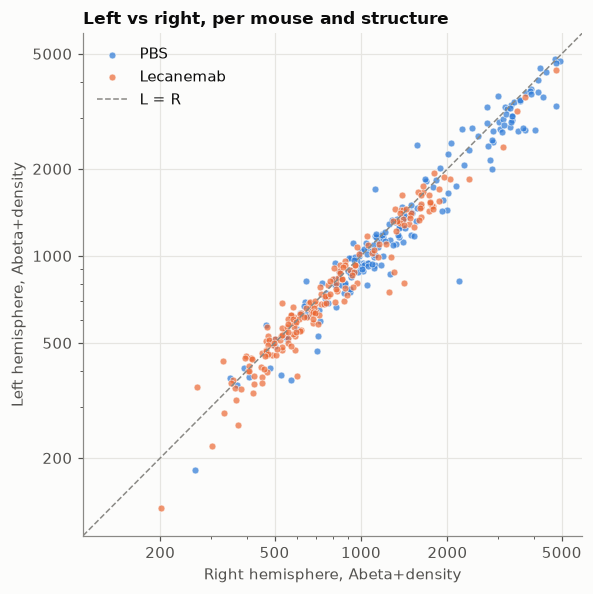

In [12]:
lr = arms_hemi.pivot_table(index=["participant_id", "treatment", "structure"], columns="hemi", values=METRIC).dropna()
lr["log2_LR"] = np.log2(lr["L"] / lr["R"])

fig, ax = plt.subplots(figsize=(5.5, 5.5))
for arm in ARMS:
    arm_lr = lr.xs(arm, level="treatment")
    ax.scatter(arm_lr["R"], arm_lr["L"], s=20, color=GROUP_COLORS[arm], alpha=0.7, edgecolors=SURFACE, linewidths=0.5, label=arm)
lims = [lr[["L", "R"]].min().min() * 0.8, lr[["L", "R"]].max().max() * 1.2]
ax.plot(lims, lims, color=MUTED, lw=1, ls="--", label="L = R")
ax.set(xscale="log", yscale="log", xlim=lims, ylim=lims, xlabel=f"Right hemisphere, {METRIC}", ylabel=f"Left hemisphere, {METRIC}")
plain_log_axes(ax)
ax.set_title("Left vs right, per mouse and structure")
ax.legend(loc="upper left")
plt.tight_layout()

print(f"log-scale L/R correlation: r = {np.corrcoef(np.log(lr['L']), np.log(lr['R']))[0, 1]:.3f}")
lr.groupby("structure")["log2_LR"].agg(["mean", "std"]).loc[STRUCTURE_ORDER].round(3)

## 4. Q2: PBS vs Lecanemab per region

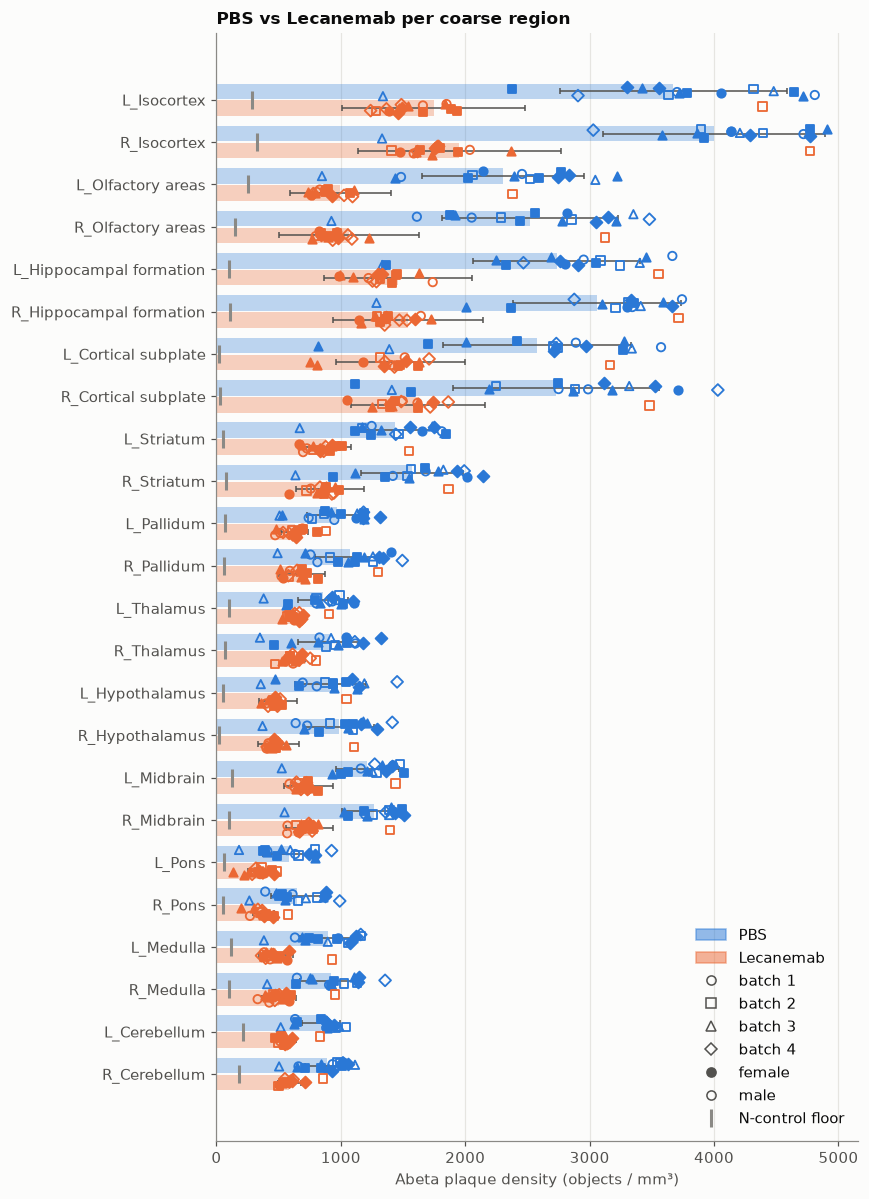

In [13]:
fig, ax = plt.subplots(figsize=(8, 11))
plot_bars_with_points(ax, arms_hemi, METRIC, ARMS, floor=ncontrol_hemi)
ax.set_xlabel(METRIC_LABEL[METRIC])
ax.set_title("PBS vs Lecanemab per coarse region")
point_legend(ax, ARMS, loc="lower right")
plt.tight_layout()

### Percent reduction per region

Reduction = 1 − mean(Lecanemab) / mean(PBS). The 95% CI is a percentile bootstrap over mice,
resampled within each arm. The dashed line is the whole-brain reduction: all regions pooled per
mouse.

The per-region test is a Welch t-test on log(metric), because a proportional effect is a shift on
the log scale. It is BH-FDR-corrected across the 24 regions.

**Batch-normalised** (hollow marker): each mouse is divided by its own batch's PBS mean for that
region before comparing. This checks that the regional pattern isn't a batch artefact.

In [14]:
def bootstrap_ratio_ci(treated, control, n_boot, rng):
    """Ratio of means treated/control with a 95% percentile CI, resampling mice within each arm."""
    treated, control = np.asarray(treated), np.asarray(control)
    boot_treated = rng.choice(treated, (n_boot, len(treated))).mean(axis=1)
    boot_control = rng.choice(control, (n_boot, len(control))).mean(axis=1)
    return treated.mean() / control.mean(), *np.percentile(boot_treated / boot_control, [2.5, 97.5])


rng = np.random.default_rng(RNG_SEED)

# Each mouse divided by its batch's PBS mean for the same region
batch_pbs_mean = pbs_hemi.groupby(["batch_id", "name"])[METRIC].mean().rename("batch_pbs_mean")
arms_hemi_norm = arms_hemi.join(batch_pbs_mean, on=["batch_id", "name"])
arms_hemi_norm["normalised"] = arms_hemi_norm[METRIC] / arms_hemi_norm["batch_pbs_mean"]

reduction_rows = []
for name, group in arms_hemi_norm.groupby("name"):
    pbs = group.loc[group["treatment"] == "PBS"]
    leca = group.loc[group["treatment"] == "Lecanemab"]
    ratio, ratio_lo, ratio_hi = bootstrap_ratio_ci(leca[METRIC], pbs[METRIC], N_BOOT, rng)
    reduction_rows.append(
        {
            "region": name,
            "PBS_mean": pbs[METRIC].mean(),
            "Lecanemab_mean": leca[METRIC].mean(),
            "reduction_pct": 100 * (1 - ratio),
            "ci_low": 100 * (1 - ratio_hi),
            "ci_high": 100 * (1 - ratio_lo),
            "reduction_batchnorm_pct": 100 * (1 - leca["normalised"].mean() / pbs["normalised"].mean()),
            "t_log": (welch := stats.ttest_ind(np.log(leca[METRIC]), np.log(pbs[METRIC]), equal_var=False)).statistic,
            "p_welch_log": welch.pvalue,
        }
    )
reduction = pd.DataFrame(reduction_rows).set_index("region")
reduction["q_fdr"] = multipletests(reduction["p_welch_log"], method="fdr_bh")[1]

whole_brain = pool_regions(arms_hemi, MOUSE_KEYS)
wb_ratio, wb_lo, wb_hi = bootstrap_ratio_ci(
    whole_brain.loc[whole_brain["treatment"] == "Lecanemab", METRIC],
    whole_brain.loc[whole_brain["treatment"] == "PBS", METRIC],
    N_BOOT,
    rng,
)
print(f"whole-brain reduction: {100 * (1 - wb_ratio):.1f}% (95% CI {100 * (1 - wb_hi):.1f} - {100 * (1 - wb_lo):.1f})")
reduction.loc[REGION_ORDER].round(3)

whole-brain reduction: 48.9% (95% CI 36.9 - 57.2)


,PBS_mean,Lecanemab_mean,reduction_pct,ci_low,ci_high,reduction_batchnorm_pct,t_log,p_welch_log,q_fdr
region,,,,,,,,,
L_Isocortex,3672.782,1745.596,52.472,38.795,61.413,52.037,-6.975,0.000,0.000
R_Isocortex,3997.425,1953.633,51.128,37.421,60.071,51.890,-6.532,0.000,0.000
L_Olfactory areas,2304.987,997.212,56.737,42.650,65.616,57.968,-7.111,0.000,0.000
R_Olfactory areas,2522.807,1067.269,57.695,43.643,66.613,58.190,-7.438,0.000,0.000
L_Hippocampal formation,2735.191,1457.502,46.713,32.231,56.427,46.436,-6.184,0.000,0.000
R_Hippocampal formation,3059.018,1540.549,49.639,37.439,58.266,50.459,-6.985,0.000,0.000
L_Cortical subplate,2579.490,1479.280,42.652,27.522,52.685,44.075,-4.394,0.000,0.000
R_Cortical subplate,2727.571,1619.117,40.639,26.449,51.465,39.603,-4.521,0.000,0.000
L_Striatum,1439.399,877.073,39.067,28.404,47.892,39.622,-5.866,0.000,0.000


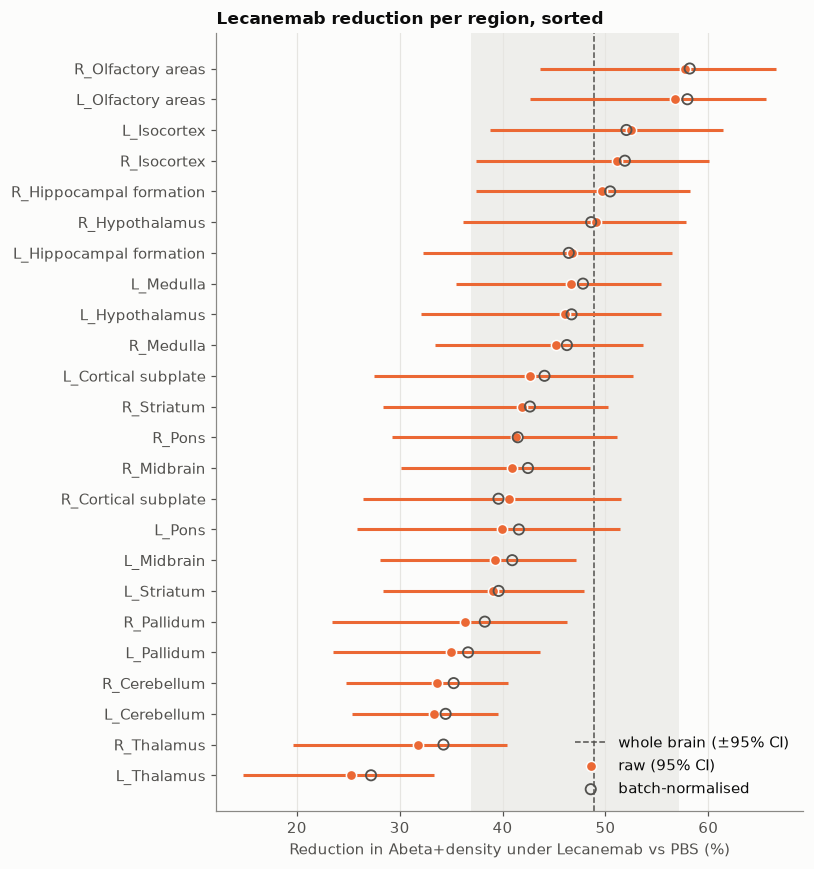

In [15]:
ordered = reduction.sort_values("reduction_pct")
y = np.arange(len(ordered))
color = GROUP_COLORS["Lecanemab"]

fig, ax = plt.subplots(figsize=(7.5, 8))
ax.axvspan(100 * (1 - wb_hi), 100 * (1 - wb_lo), color=GRID, alpha=0.6, lw=0)
ax.axvline(100 * (1 - wb_ratio), color=INK_2, lw=1, ls="--", label="whole brain (±95% CI)")
ax.hlines(y, ordered["ci_low"], ordered["ci_high"], color=color, lw=2)
ax.scatter(ordered["reduction_pct"], y, s=45, color=color, edgecolors=SURFACE, linewidths=1, zorder=3, label="raw (95% CI)")
ax.scatter(ordered["reduction_batchnorm_pct"], y, s=45, facecolors="none", edgecolors=INK_2, linewidths=1.2, zorder=3, label="batch-normalised")
ax.set_yticks(y, ordered.index)
ax.grid(axis="y", visible=False)
ax.set_xlabel(f"Reduction in {METRIC} under Lecanemab vs PBS (%)")
ax.set_title("Lecanemab reduction per region, sorted")
ax.legend(loc="lower right")
plt.tight_layout()

## 5. "Beyond baseline": the core question

The regions in section 4 start from very different PBS burdens. A lower reduction in, say,
thalamus might just be the "more plaque → more proportional removal" relationship we already know
about, applied across regions. The question is whether regions differ **beyond** that.

Everything below uses the **bilateral** table (12 structures, n = 16 + 16 mice) and log(metric).
On the log scale, a proportional effect is additive:

* uniform proportional removal → log Lecanemab = log PBS + constant (slope 1);
* removal that grows with burden → slope > 1 (high-burden regions lose proportionally more);
* region-specific removal → regions scatter off that line by more than chance.

slope-1 fit: uniform reduction 42.6%
free fit: slope 0.830 ± 0.125 (95% CI), R² 0.944


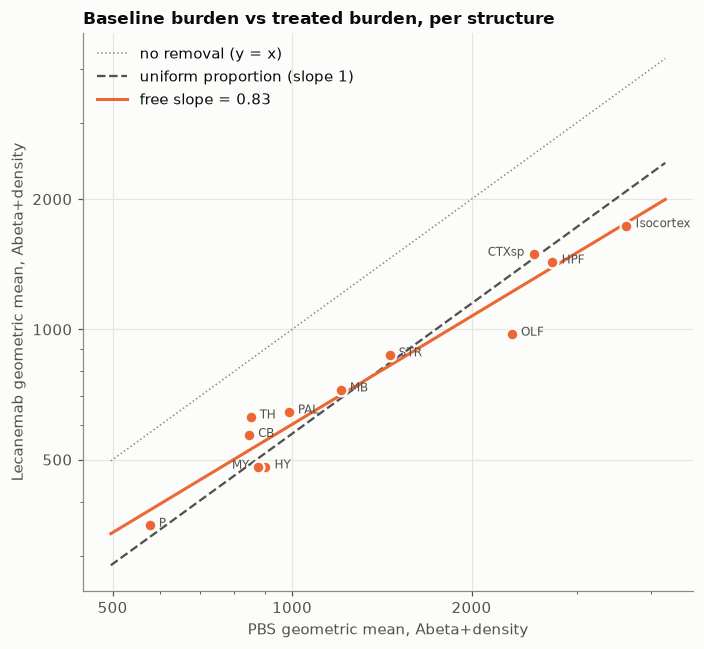

In [16]:
bilat = arms_bilat.rename(columns={"structure": "region"}).copy()
bilat["logv"] = np.log(bilat[METRIC])
bilat["leca"] = (bilat["treatment"] == "Lecanemab").astype(float)

# Geometric means per arm (mean of logs), matching the log-scale models below
region_logmeans = bilat.groupby(["region", "treatment"])["logv"].mean().unstack().loc[STRUCTURE_ORDER]
x, y = region_logmeans["PBS"], region_logmeans["Lecanemab"]

uniform_intercept = (y - x).mean()  # slope fixed at 1: one proportional reduction for every region
free_fit = stats.linregress(x, y)
print(f"slope-1 fit: uniform reduction {100 * (1 - np.exp(uniform_intercept)):.1f}%")
print(f"free fit: slope {free_fit.slope:.3f} ± {1.96 * free_fit.stderr:.3f} (95% CI), R² {free_fit.rvalue ** 2:.3f}")

fig, ax = plt.subplots(figsize=(6.5, 6))
grid_x = np.linspace(x.min() - 0.15, x.max() + 0.15, 50)
ax.plot(np.exp(grid_x), np.exp(grid_x), color=MUTED, lw=1, ls=":", label="no removal (y = x)")
ax.plot(np.exp(grid_x), np.exp(grid_x + uniform_intercept), color=INK_2, lw=1.5, ls="--", label="uniform proportion (slope 1)")
ax.plot(np.exp(grid_x), np.exp(free_fit.intercept + free_fit.slope * grid_x), color=GROUP_COLORS["Lecanemab"], lw=2, label=f"free slope = {free_fit.slope:.2f}")
ax.scatter(np.exp(x), np.exp(y), s=60, color=GROUP_COLORS["Lecanemab"], edgecolors=SURFACE, linewidths=1.5, zorder=3)
ax.set(xscale="log", yscale="log", xlabel=f"PBS geometric mean, {METRIC}", ylabel=f"Lecanemab geometric mean, {METRIC}")
plain_log_axes(ax)
ax.set_title("Baseline burden vs treated burden, per structure")
ax.legend(loc="upper left")
plt.tight_layout()
label_points(ax, np.exp(x), np.exp(y), [STRUCTURE_ABBR[r] for r in x.index])

### Split-half control for regression dilution

The full-sample fit uses the same PBS mice on the x axis and inside the treatment effect. Their
noise is shared, which biases the slope. Here the PBS mice are split in half (within batch):
half A gives the x baseline, and half B vs Lecanemab gives the log ratio. The slope below is in
the **log-ratio** frame, so 0 = uniform proportion. It equals the scatter slope − 1.

split-half slope: median -0.169, 95% range -0.233 - -0.104; fraction of splits > 0: 0.000


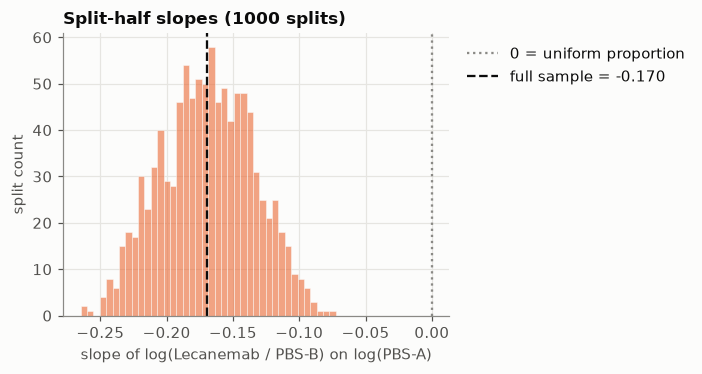

In [17]:
def split_half_slopes(bilat_table, n_splits, rng):
    pbs = bilat_table[bilat_table["treatment"] == "PBS"]
    pbs_wide = pbs.pivot(index="participant_id", columns="region", values="logv")[STRUCTURE_ORDER]
    leca_mean = bilat_table[bilat_table["treatment"] == "Lecanemab"].groupby("region")["logv"].mean()[STRUCTURE_ORDER]
    ids_by_batch = [g["participant_id"].unique() for _, g in pbs.groupby("batch_id")]
    slopes = np.empty(n_splits)
    for i in range(n_splits):
        half_a = []
        for ids in ids_by_batch:
            shuffled = rng.permutation(ids)
            # odd-sized batches send the extra mouse to either half at random
            half_a.extend(shuffled[: len(ids) // 2 + (len(ids) % 2) * rng.integers(2)])
        half_b = pbs_wide.index.difference(half_a)
        baseline = pbs_wide.loc[half_a].mean()
        log_ratio = leca_mean - pbs_wide.loc[half_b].mean()
        slopes[i] = np.polyfit(baseline, log_ratio, 1)[0]
    return slopes


split_slopes = split_half_slopes(bilat, N_SPLITS, np.random.default_rng(RNG_SEED))
full_ratio_slope = free_fit.slope - 1

fig, ax = plt.subplots(figsize=(6.5, 3.5))
ax.hist(split_slopes, bins=40, color=GROUP_COLORS["Lecanemab"], alpha=0.6, edgecolor=SURFACE, linewidth=0.5)
ax.axvline(0, color=MUTED, ls=":", lw=1.5, label="0 = uniform proportion")
ax.axvline(full_ratio_slope, color=INK, ls="--", lw=1.5, label=f"full sample = {full_ratio_slope:.3f}")
ax.set_xlabel("slope of log(Lecanemab / PBS-B) on log(PBS-A)")
ax.set_ylabel("split count")
ax.set_title(f"Split-half slopes ({N_SPLITS} splits)")
ax.legend(loc="upper left", bbox_to_anchor=(1.01, 1))
plt.tight_layout()
print(f"split-half slope: median {np.median(split_slopes):.3f}, 95% range "
      f"{np.percentile(split_slopes, 2.5):.3f} - {np.percentile(split_slopes, 97.5):.3f}; "
      f"fraction of splits > 0: {(split_slopes > 0).mean():.3f}")

### Nested mixed models

The models use log(metric), a random intercept per mouse (the 12 regions are repeated measures
within a mouse) and a fixed effect of batch. They are fitted by ML (`reml=False`) so the nested
likelihoods are comparable. `leca` is a 0/1 indicator, and `base_c` is the region's log PBS mean
(centred), a covariate at the region level.

| model | formula | meaning |
|---|---|---|
| M0 | `region + batch + leca` | one proportional effect everywhere |
| M1 | M0 `+ leca:base_c` | the proportion depends on regional burden |
| M2 | M1 `+ leca:region` | the proportion is region-specific, beyond burden |

* **M1 vs M0** asks: does the proportion depend on burden?
* **M2 vs M1** asks: does it differ by region beyond baseline? This is the proposal's question.

`leca:base_c` lies inside the column space of `leca:region`, because `base_c` is constant within a
region. So M2 is fitted as `region + batch + leca + leca:region`: the fitted values are the same
and the design is full rank. M2 vs M1 then has R − 2 = 10 df. This is checked below. The term is
written with the numeric `leca` rather than `C(treatment):base_c`, because the categorical form
would repeat `base_c` inside the region main effect.

In [18]:
F_M0 = "logv ~ C(region) + C(batch_id) + leca"
F_M1 = F_M0 + " + leca:base_c"
F_M2 = F_M0 + " + leca:C(region)"
MODELS = {"M0": F_M0, "M1": F_M1, "M2": F_M2}


def add_baseline(data):
    """Region baseline = mean log metric of the rows currently labelled PBS, centred across regions."""
    baseline = data[data["leca"] == 0].groupby("region")["logv"].mean()
    return data.assign(base_c=data["region"].map(baseline - baseline.mean()))


def fit_mixed(formula, data):
    """ML mixed-model fit with a random intercept per mouse; returns (result, converged).

    On resampled or permuted data, L-BFGS sometimes stops where the Hessian can't be inverted even
    though the design is full rank. Other optimisers are tried in turn before giving up with
    (None, False), so the caller can skip and count it rather than abort a 1000-iteration loop.
    """
    model = smf.mixedlm(formula, data, groups=data["participant_id"])
    for method in ["lbfgs", "bfgs", "powell"]:
        with warnings.catch_warnings(record=True) as caught:
            warnings.simplefilter("always")
            try:
                result = model.fit(reml=False, method=[method])
            except np.linalg.LinAlgError:
                continue
        converged = result.converged and not any(issubclass(w.category, ConvergenceWarning) for w in caught)
        return result, converged
    return None, False


def compare_models(data):
    """LR statistics for M1 vs M0 and M2 vs M1 (NaN if any fit failed), plus the fits themselves."""
    data = add_baseline(data)
    fits = {name: fit_mixed(formula, data) for name, formula in MODELS.items()}
    n_not_converged = sum(not converged for _, converged in fits.values())
    if any(result is None for result, _ in fits.values()):
        return np.nan, np.nan, n_not_converged, fits
    llf = {name: result.llf for name, (result, _) in fits.items()}
    return 2 * (llf["M1"] - llf["M0"]), 2 * (llf["M2"] - llf["M1"]), n_not_converged, fits


bilat = add_baseline(bilat)

# Identifiability check: adding leca:base_c to M2's design must not add a dimension
design_m2 = patsy.dmatrix(F_M2.split("~")[1], bilat, return_type="dataframe")
design_m2_plus = np.column_stack([design_m2, bilat["leca"] * bilat["base_c"]])
design_m1 = patsy.dmatrix(F_M1.split("~")[1], bilat, return_type="dataframe")
assert np.linalg.matrix_rank(design_m1) == design_m1.shape[1]
assert np.linalg.matrix_rank(design_m2) == design_m2.shape[1] == np.linalg.matrix_rank(design_m2_plus)
DF_01 = 1
DF_12 = design_m2.shape[1] - design_m1.shape[1]
assert DF_12 == bilat["region"].nunique() - 2

lr_01, lr_12, n_bad, observed_fits = compare_models(bilat)
assert lr_01 >= 0 and lr_12 >= 0 and n_bad == 0
print(observed_fits["M1"][0].summary().tables[1].loc[["leca", "leca:base_c"]])
print(f"\nLR M1 vs M0 = {lr_01:.2f} (df {DF_01}); LR M2 vs M1 = {lr_12:.2f} (df {DF_12})")

              Coef. Std.Err.       z  P>|z|  [0.025  0.975]
leca         -0.583    0.078  -7.472  0.000  -0.736  -0.430
leca:base_c  -0.167    0.026  -6.402  0.000  -0.218  -0.116

LR M1 vs M0 = 38.76 (df 1); LR M2 vs M1 = 69.35 (df 10)


### Permutation p-values

Mice are shuffled between the PBS and Lecanemab labels **within each batch**, so each batch keeps
its arm sizes. On every permutation the region baseline is **recomputed from the permuted PBS
mice** (otherwise it would carry the true labels) and all three models are refitted. The χ² LRT
p-values are shown for reference only: with 32 mice and a random effect, the permutation null is
the one to trust.

In [19]:
def permute_within_batch(data, rng):
    mouse_arms = data[["participant_id", "batch_id", "leca"]].drop_duplicates()
    shuffled = mouse_arms.groupby("batch_id")["leca"].transform(lambda s: rng.permutation(s.to_numpy()))
    return data.assign(leca=data["participant_id"].map(dict(zip(mouse_arms["participant_id"], shuffled))))


def permutation_null(data, n_perm, rng):
    null = np.empty((n_perm, 2))
    n_not_converged = 0
    for i in range(n_perm):
        null[i, 0], null[i, 1], bad, _ = compare_models(permute_within_batch(data, rng))
        n_not_converged += bad
    return null, n_not_converged


def perm_p(null_stats, observed):
    null_stats = null_stats[~np.isnan(null_stats)]
    return (1 + np.sum(null_stats >= observed)) / (1 + len(null_stats))


perm_null, perm_not_converged = permutation_null(bilat, N_PERM, np.random.default_rng(RNG_SEED))
perm_failed = np.isnan(perm_null[:, 0])
perm_null = perm_null[~perm_failed]
print(f"{N_PERM} permutations; {perm_failed.sum()} dropped because a fit failed")

model_tests = pd.DataFrame(
    {
        "question": ["proportion depends on burden", "region-specific beyond burden"],
        "LR": [lr_01, lr_12],
        "df": [DF_01, DF_12],
        "p_chi2 (reference)": [stats.chi2.sf(lr_01, DF_01), stats.chi2.sf(lr_12, DF_12)],
        "p_permutation": [perm_p(perm_null[:, 0], lr_01), perm_p(perm_null[:, 1], lr_12)],
        "null_mean_LR": perm_null.mean(axis=0),
    },
    index=["M1 vs M0", "M2 vs M1"],
)
print(f"{N_PERM} permutations x 3 models; fits not converged: {perm_not_converged} / {3 * N_PERM}")
model_tests.round(4)

1000 permutations; 0 dropped because a fit failed
1000 permutations x 3 models; fits not converged: 0 / 3000


,question,LR,df,p_chi2 (reference),p_permutation,null_mean_LR
M1 vs M0,proportion depends on burden,38.7608,1,0.0,0.003,3.8760
M2 vs M1,region-specific beyond burden,69.3483,10,0.0,0.001,7.4944


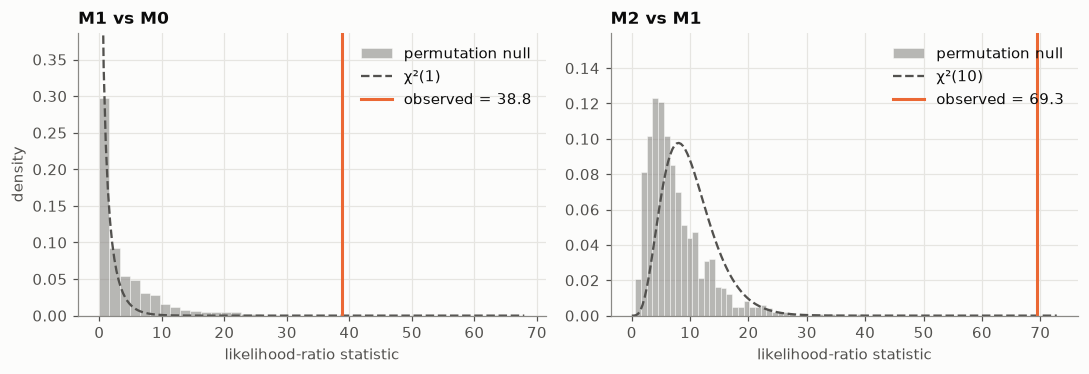

In [20]:
fig, axes = plt.subplots(1, 2, figsize=(10, 3.5))
for ax, col, observed, df, title in zip(axes, [0, 1], [lr_01, lr_12], [DF_01, DF_12], model_tests.index):
    heights, _, _ = ax.hist(perm_null[:, col], bins=40, density=True, color=MUTED, alpha=0.6, edgecolor=SURFACE, linewidth=0.5, label="permutation null")
    grid = np.linspace(0.01, max(perm_null[:, col].max(), observed) * 1.05, 200)
    ax.plot(grid, stats.chi2.pdf(grid, df), color=INK_2, lw=1.5, ls="--", label=f"χ²({df})")
    ax.axvline(observed, color=GROUP_COLORS["Lecanemab"], lw=2, label=f"observed = {observed:.1f}")
    ax.set_ylim(0, heights.max() * 1.3)  # chi2(1) density diverges at 0; keep the histogram readable
    ax.set_xlabel("likelihood-ratio statistic")
    ax.set_title(title)
    ax.legend(loc="upper right")
axes[0].set_ylabel("density")
plt.tight_layout()

### Region-specific effects beyond baseline

For each region, M2's Lecanemab/PBS ratio is divided by the ratio M1 predicts from that region's
baseline.

* 1 means the region behaves as its burden predicts;
* < 1 means more removal than predicted;
* > 1 means less removal than predicted.

The 95% CIs come from a bootstrap that resamples mice within arm × batch, recomputing the baseline
and refitting both models each time.

In [21]:
def region_effects(data):
    """exp(M2 region log ratio - M1 burden-predicted log ratio), plus M2's own region ratios."""
    data = add_baseline(data)
    m1, m2 = fit_mixed(F_M1, data)[0], fit_mixed(F_M2, data)[0]
    if m1 is None or m2 is None:
        return None
    m1, m2 = m1.fe_params, m2.fe_params
    base_c = data.groupby("region")["base_c"].first()
    # treatment coding: the alphabetically first region is the reference, with no interaction term
    m2_log_ratio = pd.Series({r: m2["leca"] + m2.get(f"leca:C(region)[T.{r}]", 0.0) for r in base_c.index})
    m1_log_ratio = m1["leca"] + m1["leca:base_c"] * base_c
    return np.exp(m2_log_ratio - m1_log_ratio), np.exp(m2_log_ratio)


def bootstrap_mice(data, rng):
    """Resample mice with replacement within arm x batch; duplicates become distinct mice."""
    mouse_strata = data[["participant_id", "batch_id", "leca"]].drop_duplicates()
    picks = mouse_strata.groupby(["batch_id", "leca"])["participant_id"].transform(
        lambda s: rng.choice(s.to_numpy(), len(s))
    )
    by_mouse = dict(tuple(data.groupby("participant_id")))
    return pd.concat(
        [by_mouse[pid].assign(participant_id=f"{pid}#{k}") for k, pid in enumerate(picks)], ignore_index=True
    )


beyond, m2_ratio = region_effects(bilat)
boot_rng = np.random.default_rng(RNG_SEED)
boot_results = [region_effects(bootstrap_mice(bilat, boot_rng)) for _ in range(N_BOOT_MODEL)]
boot_beyond = pd.DataFrame([r[0] for r in boot_results if r is not None])
print(f"{N_BOOT_MODEL} bootstrap resamples; {N_BOOT_MODEL - len(boot_beyond)} dropped because a fit failed")

region_beyond = pd.DataFrame(
    {
        "abbr": [STRUCTURE_ABBR[r] for r in beyond.index],
        "M2_ratio": m2_ratio,
        "beyond_baseline": beyond,
        "ci_low": boot_beyond.quantile(0.025),
        "ci_high": boot_beyond.quantile(0.975),
    }
)
region_beyond["ci_excludes_1"] = (region_beyond["ci_low"] > 1) | (region_beyond["ci_high"] < 1)
region_beyond.loc[STRUCTURE_ORDER].round(3)

500 bootstrap resamples; 0 dropped because a fit failed


,abbr,M2_ratio,beyond_baseline,ci_low,ci_high,ci_excludes_1
Isocortex,Isocortex,0.465,0.985,0.942,1.030,False
Olfactory areas,OLF,0.407,0.800,0.753,0.846,True
Hippocampal formation,HPF,0.511,1.030,0.990,1.081,False
Cortical subplate,CTXsp,0.571,1.139,1.083,1.199,True
Striatum,STR,0.585,1.062,1.031,1.096,True
Pallidum,PAL,0.637,1.084,1.033,1.137,True
Thalamus,TH,0.718,1.194,1.133,1.253,True
Hypothalamus,HY,0.515,0.863,0.816,0.918,True
Midbrain,MB,0.579,1.020,0.986,1.057,False
Pons,P,0.590,0.918,0.856,0.973,True


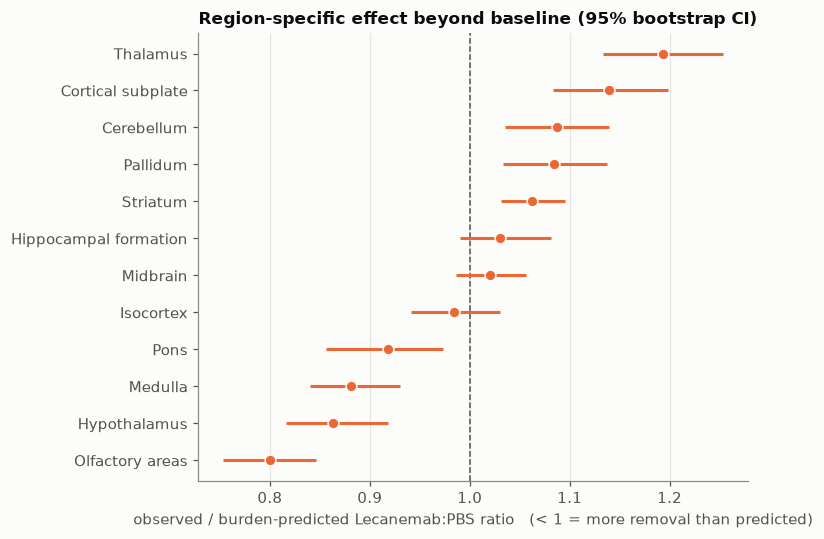

In [22]:
ordered = region_beyond.sort_values("beyond_baseline")
y = np.arange(len(ordered))
fig, ax = plt.subplots(figsize=(7, 5))
ax.axvline(1, color=INK_2, lw=1, ls="--")
ax.hlines(y, ordered["ci_low"], ordered["ci_high"], color=GROUP_COLORS["Lecanemab"], lw=2)
ax.scatter(ordered["beyond_baseline"], y, s=50, color=GROUP_COLORS["Lecanemab"], edgecolors=SURFACE, linewidths=1, zorder=3)
ax.set_yticks(y, ordered.index)
ax.grid(axis="y", visible=False)
ax.set_xlabel("observed / burden-predicted Lecanemab:PBS ratio   (< 1 = more removal than predicted)")
ax.set_title("Region-specific effect beyond baseline (95% bootstrap CI)")
plt.tight_layout()

### Sensitivity checks

The scatter slope and both model comparisons (χ² LRT only) are re-run under alternative choices:

* QC exclusions flipped;
* the other metric;
* brainstem structures dropped: they have the lowest burden and sit closest to the N-control
  floor;
* any structure flagged as near the floor dropped.

The permutation test is run only for the main specification above.

In [23]:
def run_spec(apply_qc, metric, drop_regions=()):
    _, spec_bilat = build_tables(apply_qc)
    spec = spec_bilat.rename(columns={"structure": "region"})
    spec = spec[~spec["region"].isin(drop_regions)].copy()
    spec["logv"] = np.log(spec[metric])
    spec["leca"] = (spec["treatment"] == "Lecanemab").astype(float)
    logmeans = spec.groupby(["region", "treatment"])["logv"].mean().unstack()
    n_regions = spec["region"].nunique()
    lr01, lr12, n_bad, _ = compare_models(spec)
    return {
        "n_regions": n_regions,
        "scatter_slope": stats.linregress(logmeans["PBS"], logmeans["Lecanemab"]).slope,
        "LR_M1_M0": lr01,
        "p_chi2_M1_M0": stats.chi2.sf(lr01, 1),
        "LR_M2_M1": lr12,
        "p_chi2_M2_M1": stats.chi2.sf(lr12, n_regions - 2),
        "not_converged": n_bad,
    }


other_metric = "Abeta+fieldfrac" if METRIC == "Abeta+density" else "Abeta+density"
brainstem = ["Midbrain", "Pons", "Medulla"]
near_floor = floor_check.index[floor_check["near_floor"]].tolist()

specs = {
    "main": (APPLY_QC_EXCLUSIONS, METRIC, ()),
    f"QC exclusions {'off' if APPLY_QC_EXCLUSIONS else 'on'}": (not APPLY_QC_EXCLUSIONS, METRIC, ()),
    other_metric: (APPLY_QC_EXCLUSIONS, other_metric, ()),
    "no brainstem": (APPLY_QC_EXCLUSIONS, METRIC, brainstem),
}
if near_floor:
    specs["no near-floor regions"] = (APPLY_QC_EXCLUSIONS, METRIC, near_floor)
print(f"structures within {FLOOR_FACTOR}x of the N-control floor: {near_floor or 'none'}")

sensitivity = pd.DataFrame({name: run_spec(*args) for name, args in specs.items()}).T
sensitivity.round(4)

structures within 2x of the N-control floor: none


,n_regions,scatter_slope,LR_M1_M0,p_chi2_M1_M0,LR_M2_M1,p_chi2_M2_M1,not_converged
main,12.0,0.8305,38.7608,0.0000,69.3483,0.0,0.0
QC exclusions off,12.0,0.8335,38.7069,0.0000,67.0195,0.0,0.0
Abeta+fieldfrac,12.0,1.1185,16.3127,0.0001,63.3568,0.0,0.0
no brainstem,9.0,0.7784,48.2431,0.0000,57.1135,0.0,0.0


## 6. Summary and next steps

SUMMARY_PLACEHOLDER